In [1]:

import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

h5_path = Path("/ceph/srv/dwong/training_samples_h5/ER/ER_traces_energy_500_batch_0240.h5")

with h5py.File(h5_path, "r") as f:
    print("file attrs:", dict(f.attrs))
    traces = f["traces"]      # dataset: (batch_size, n_channels, trace_samples), float16
    events = f["events"]      # structured array with x/y/z/energy/type_recoil/no_noise/quantize

    print("traces shape:", traces.shape, "dtype:", traces.dtype)
    print("traces attrs:", dict(traces.attrs))
    print("events dtype names:", events.dtype.names)
    print("events attrs:", dict(events.attrs))

    # pull one event
    i = 0
    trace_i = traces[i]       # numpy array (n_channels, trace_samples)
    meta_i = events[i]        # structured record
    first_trace = trace_i

# decode bytes to str for display
meta_dict = {}
for name in events.dtype.names:
    val = meta_i[name]
    if isinstance(val, (bytes, bytearray)):
        val = val.decode("utf-8")
    meta_dict[name] = val
print("first event meta:", meta_dict)
print("type_recoil str:", meta_dict.get("type_recoil"))

print("first_trace shape:", first_trace.shape)


file attrs: {}
traces shape: (100, 56, 65536) dtype: float16
traces attrs: {}
events dtype names: ('x', 'y', 'z', 'energy', 'type_recoil', 'no_noise', 'quantize')
events attrs: {}
first event meta: {'x': 108.54813723454457, 'y': 33.46085755639923, 'z': -1703.767603743275, 'energy': 500.0, 'type_recoil': 'ER', 'no_noise': False, 'quantize': True}
type_recoil str: ER
first_trace shape: (56, 65536)


In [2]:
def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 44 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()

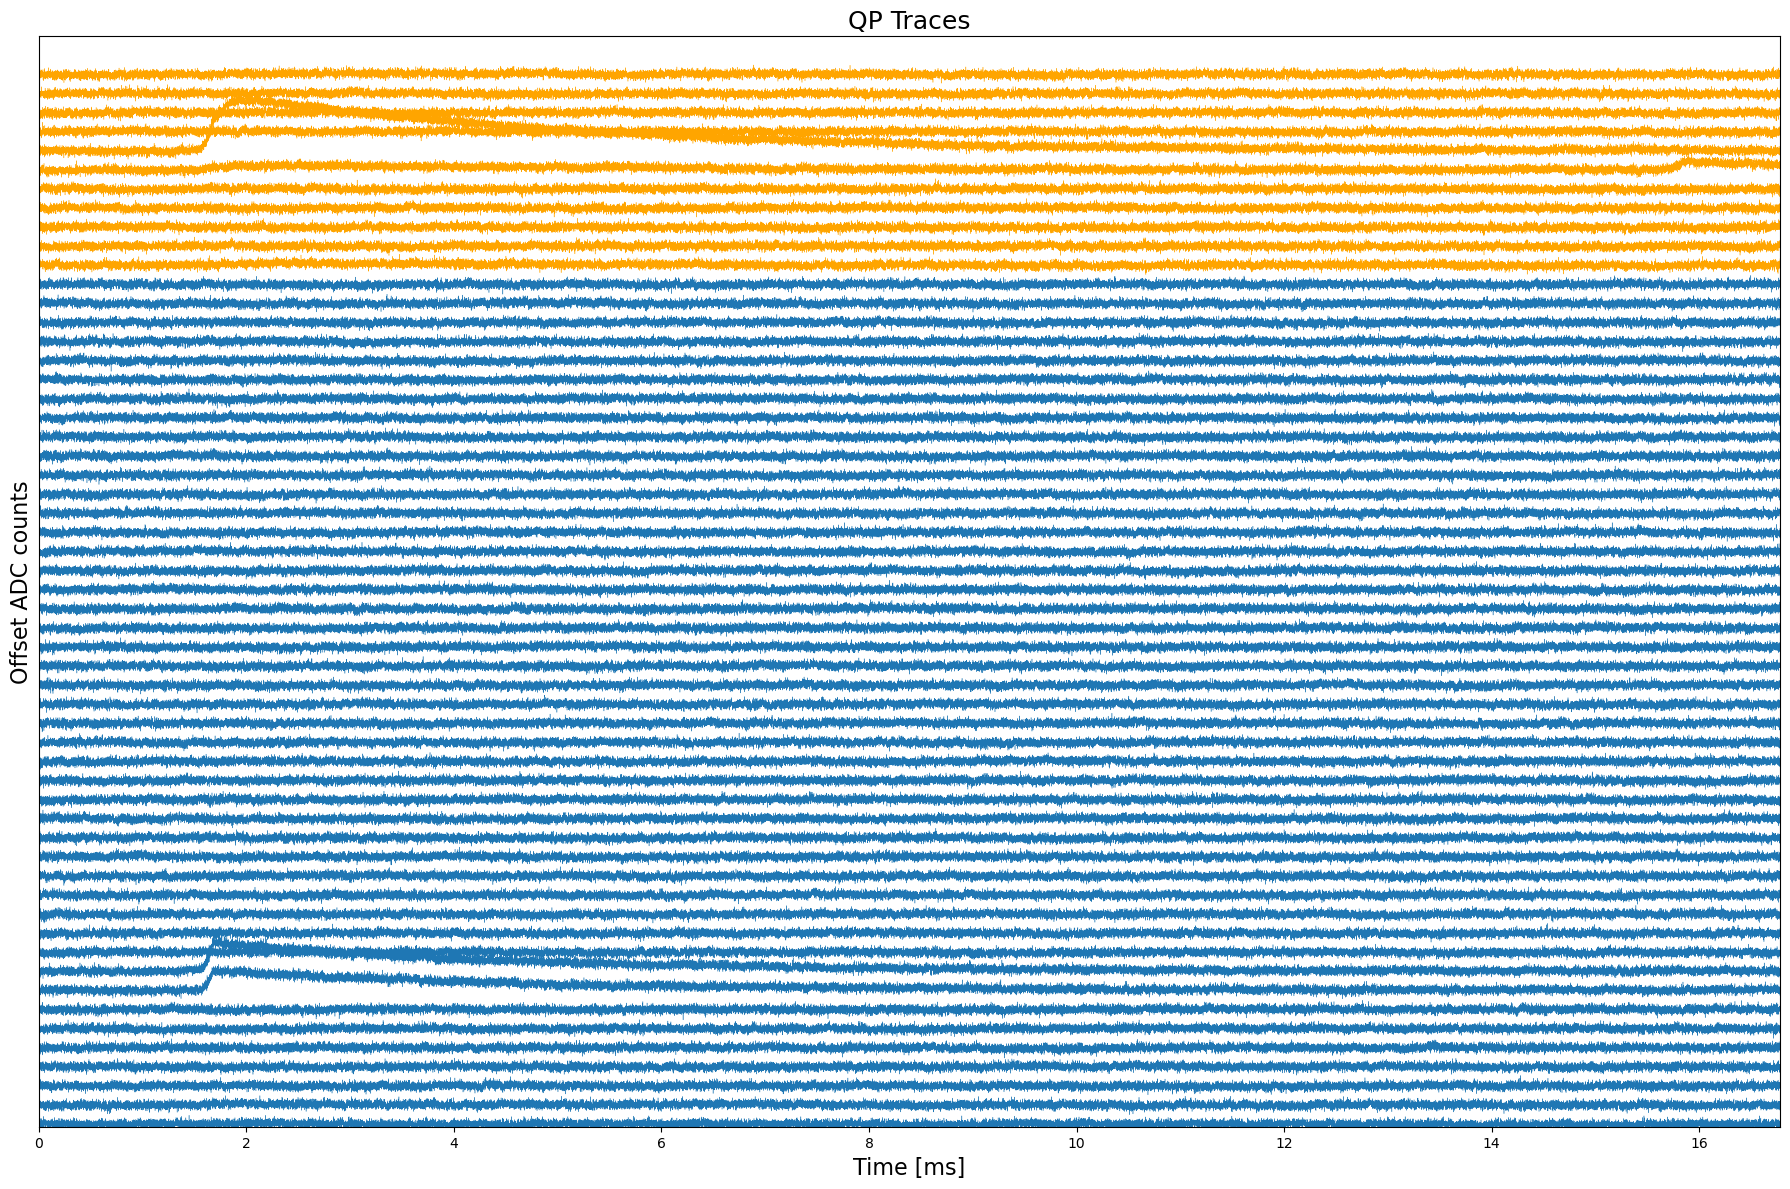

In [3]:
plot_traces(first_trace)